In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

import requests

## Leanring rate 1e-3

In [2]:
# Load your CSVs
unet_df = pd.read_csv("history/Unet-1.csv")
swin_df = pd.read_csv("history/SwinUnet-1.csv")
deeplab_df = pd.read_csv("history/DeepLab-1.csv")

LR = 1e-3

# Add model names
unet_df["model"] = "UNet"
swin_df["model"] = "Swin"
deeplab_df["model"] = "DeepLab"

unet_df["train_dice_score"] = (2*unet_df["train_iou"])/(1+unet_df["train_iou"])
unet_df["val_dice_score"] = (2*unet_df["val_iou"])/(1+unet_df["val_iou"])
swin_df["train_dice_score"] = (2*swin_df["train_iou"])/(1+swin_df["train_iou"])
swin_df["val_dice_score"] = (2*swin_df["val_iou"])/(1+swin_df["val_iou"])
deeplab_df["train_dice_score"] = (2*deeplab_df["train_iou"])/(1+deeplab_df["train_iou"])
deeplab_df["val_dice_score"] = (2*deeplab_df["val_iou"])/(1+deeplab_df["val_iou"])

# Combine
df = pd.concat([unet_df, swin_df, deeplab_df], ignore_index=True)

# Ensure epoch is int (optional cleanup)
df["epoch"] = df["epoch"].astype(int)

In [3]:
# Add model labels
unet_df["model"] = "UNet"
swin_df["model"] = "Swin"
deeplab_df["model"] = "DeepLab"

# Combine
df = pd.concat([unet_df, swin_df, deeplab_df], ignore_index=True)
df["epoch"] = df["epoch"].astype(int)

sns.set(style="whitegrid", context="talk")

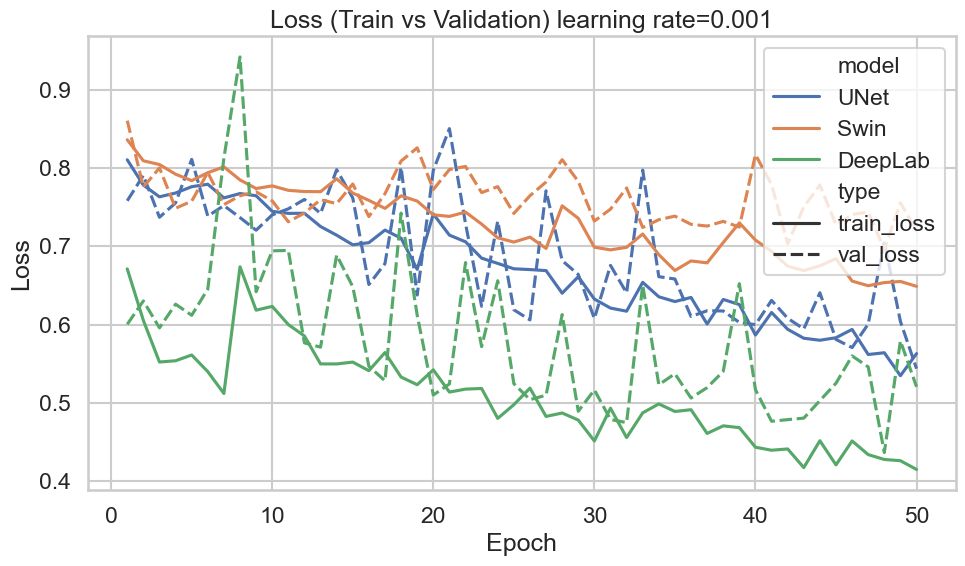

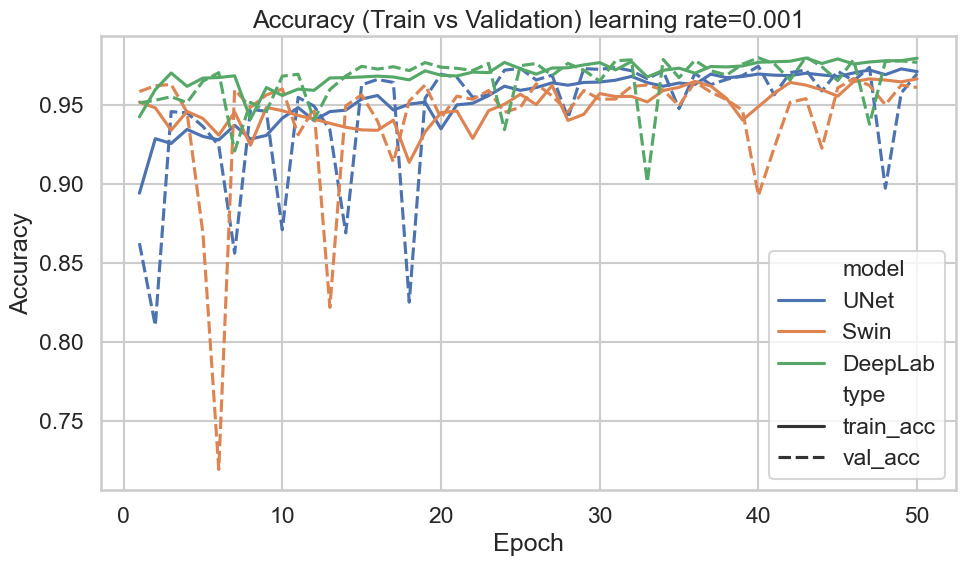

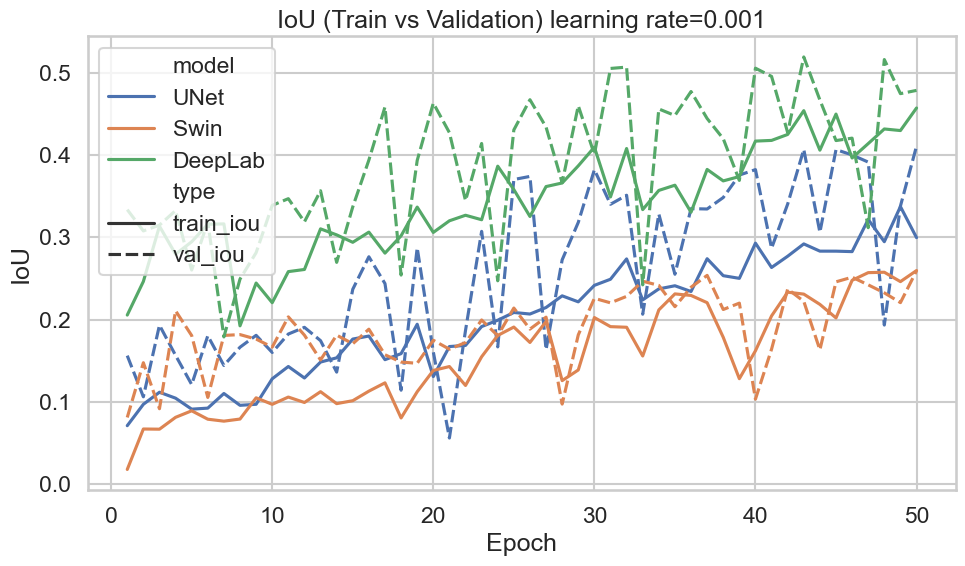

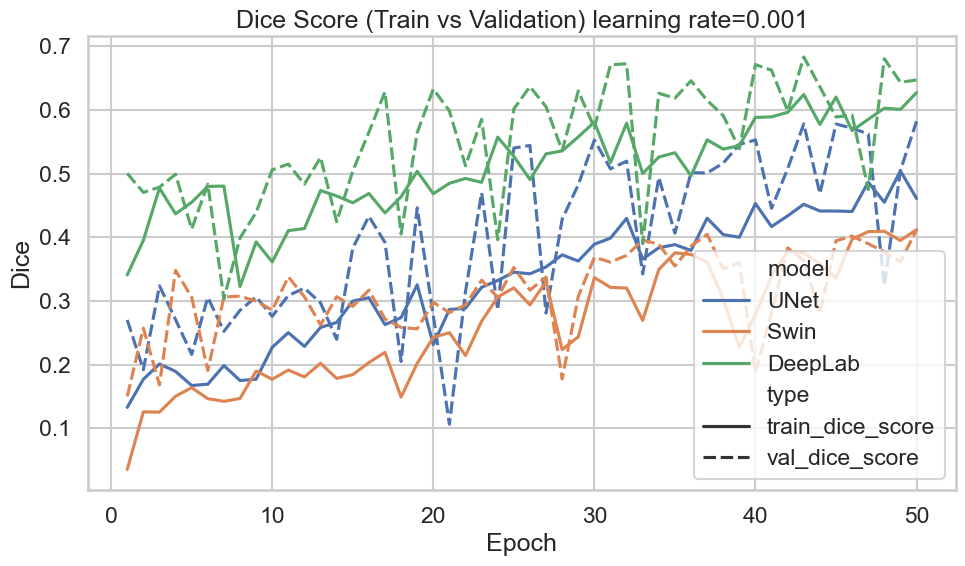

In [4]:
# -------------------------
# 1. LOSS
# -------------------------
loss_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_loss", "val_loss"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=loss_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Loss (Train vs Validation) learning rate={LR}")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()


# -------------------------
# 2. ACCURACY
# -------------------------
acc_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_acc", "val_acc"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=acc_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Accuracy (Train vs Validation) learning rate={LR}")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()


# -------------------------
# 3. IoU
# -------------------------
iou_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_iou", "val_iou"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=iou_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"IoU (Train vs Validation) learning rate={LR}")
plt.ylabel("IoU")
plt.xlabel("Epoch")

# # Optional: log scale for visibility
# plt.yscale("log")

plt.tight_layout()
plt.show()


# -------------------------
# 3. Dice Score
# -------------------------
iou_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_dice_score", "val_dice_score"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=iou_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Dice Score (Train vs Validation) learning rate={LR}")
plt.ylabel("Dice")
plt.xlabel("Epoch")

# # Optional: log scale for visibility
# plt.yscale("log")

plt.tight_layout()
plt.show()

## Learning rate 1e-4

In [5]:
# Load your CSVs
unet_df = pd.read_csv("history/Unet-2.csv")
swin_df = pd.read_csv("history/SwinUnet-2.csv")
deeplab_df = pd.read_csv("history/DeepLab-2.csv")

LR = 1e-4

# Add model names
unet_df["model"] = "UNet"
swin_df["model"] = "Swin"
deeplab_df["model"] = "DeepLab"

unet_df["train_dice_score"] = (2*unet_df["train_iou"])/(1+unet_df["train_iou"])
unet_df["val_dice_score"] = (2*unet_df["val_iou"])/(1+unet_df["val_iou"])
swin_df["train_dice_score"] = (2*swin_df["train_iou"])/(1+swin_df["train_iou"])
swin_df["val_dice_score"] = (2*swin_df["val_iou"])/(1+swin_df["val_iou"])
deeplab_df["train_dice_score"] = (2*deeplab_df["train_iou"])/(1+deeplab_df["train_iou"])
deeplab_df["val_dice_score"] = (2*deeplab_df["val_iou"])/(1+deeplab_df["val_iou"])

# Combine
df = pd.concat([unet_df, swin_df, deeplab_df], ignore_index=True)

# Ensure epoch is int (optional cleanup)
df["epoch"] = df["epoch"].astype(int)

In [6]:
# Add model labels
unet_df["model"] = "UNet"
swin_df["model"] = "Swin"
deeplab_df["model"] = "DeepLab"

# Combine
df = pd.concat([unet_df, swin_df, deeplab_df], ignore_index=True)
df["epoch"] = df["epoch"].astype(int)

sns.set(style="whitegrid", context="talk")

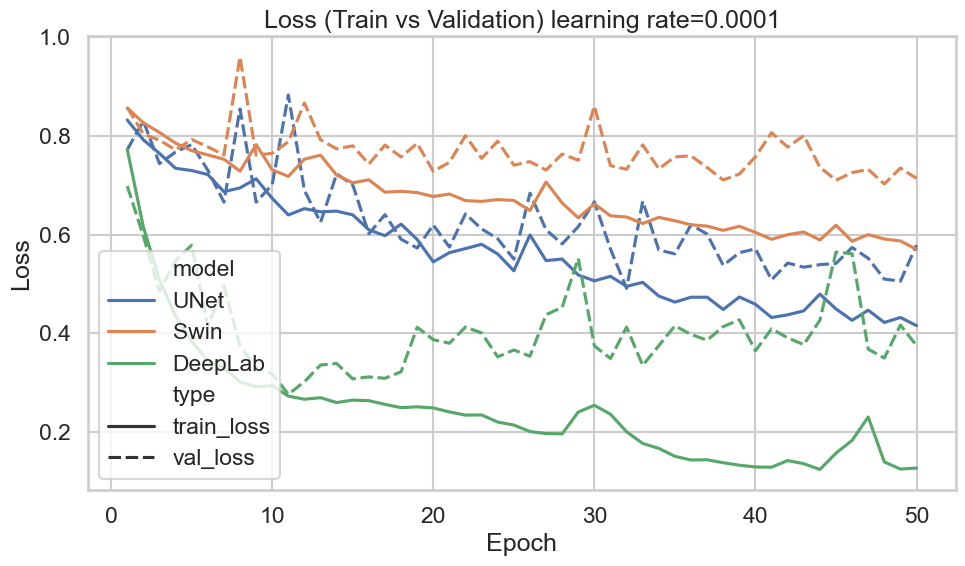

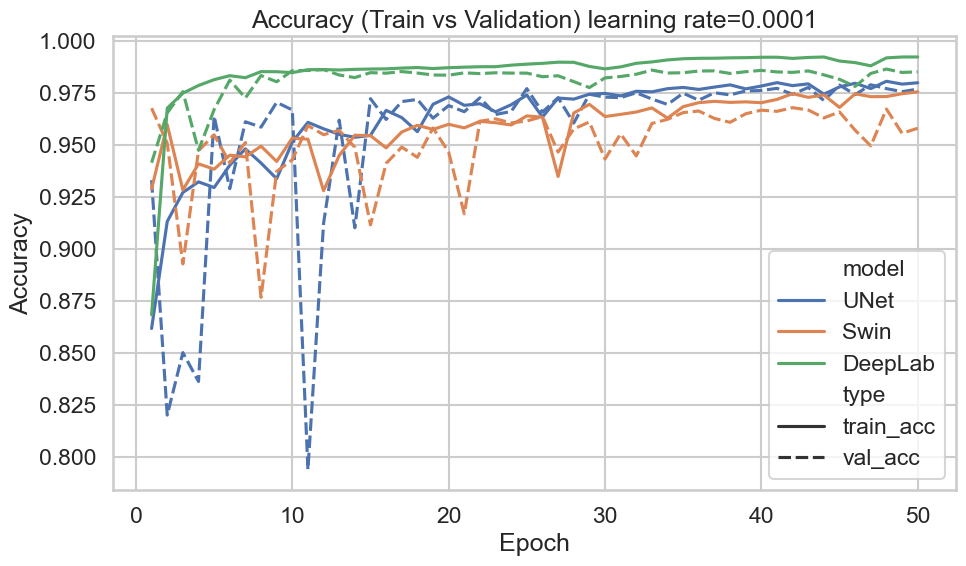

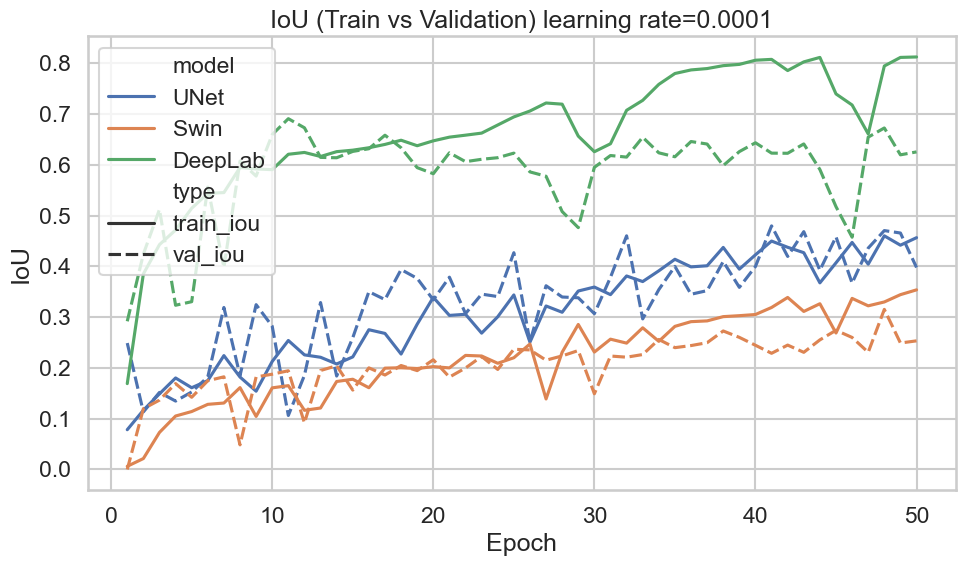

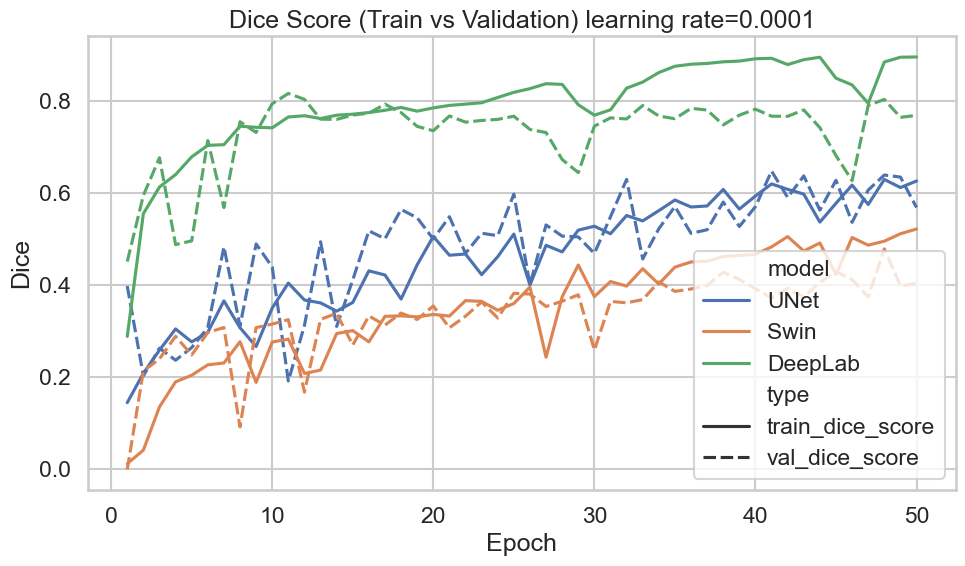

In [7]:
# -------------------------
# 1. LOSS
# -------------------------
loss_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_loss", "val_loss"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=loss_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Loss (Train vs Validation) learning rate={LR}")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()


# -------------------------
# 2. ACCURACY
# -------------------------
acc_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_acc", "val_acc"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=acc_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Accuracy (Train vs Validation) learning rate={LR}")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()


# -------------------------
# 3. IoU
# -------------------------
iou_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_iou", "val_iou"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=iou_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"IoU (Train vs Validation) learning rate={LR}")
plt.ylabel("IoU")
plt.xlabel("Epoch")

# # Optional: log scale for visibility
# plt.yscale("log")

plt.tight_layout()
plt.show()


# -------------------------
# 3. Dice Score
# -------------------------
iou_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_dice_score", "val_dice_score"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=iou_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Dice Score (Train vs Validation) learning rate={LR}")
plt.ylabel("Dice")
plt.xlabel("Epoch")

# # Optional: log scale for visibility
# plt.yscale("log")

plt.tight_layout()
plt.show()

## Learning rate 1e-5

In [8]:
# Load your CSVs
unet_df = pd.read_csv("history/Unet-2.csv")
swin_df = pd.read_csv("history/SwinUnet-2.csv")
deeplab_df = pd.read_csv("history/DeepLab-2.csv")

LR = 1e-4

# Add model names
unet_df["model"] = "UNet"
swin_df["model"] = "Swin"
deeplab_df["model"] = "DeepLab"

unet_df["train_dice_score"] = (2*unet_df["train_iou"])/(1+unet_df["train_iou"])
unet_df["val_dice_score"] = (2*unet_df["val_iou"])/(1+unet_df["val_iou"])
swin_df["train_dice_score"] = (2*swin_df["train_iou"])/(1+swin_df["train_iou"])
swin_df["val_dice_score"] = (2*swin_df["val_iou"])/(1+swin_df["val_iou"])
deeplab_df["train_dice_score"] = (2*deeplab_df["train_iou"])/(1+deeplab_df["train_iou"])
deeplab_df["val_dice_score"] = (2*deeplab_df["val_iou"])/(1+deeplab_df["val_iou"])

# Combine
df = pd.concat([unet_df, swin_df, deeplab_df], ignore_index=True)

# Ensure epoch is int (optional cleanup)
df["epoch"] = df["epoch"].astype(int)

In [9]:
# Add model labels
unet_df["model"] = "UNet"
swin_df["model"] = "Swin"
deeplab_df["model"] = "DeepLab"

# Combine
df = pd.concat([unet_df, swin_df, deeplab_df], ignore_index=True)
df["epoch"] = df["epoch"].astype(int)

sns.set(style="whitegrid", context="talk")

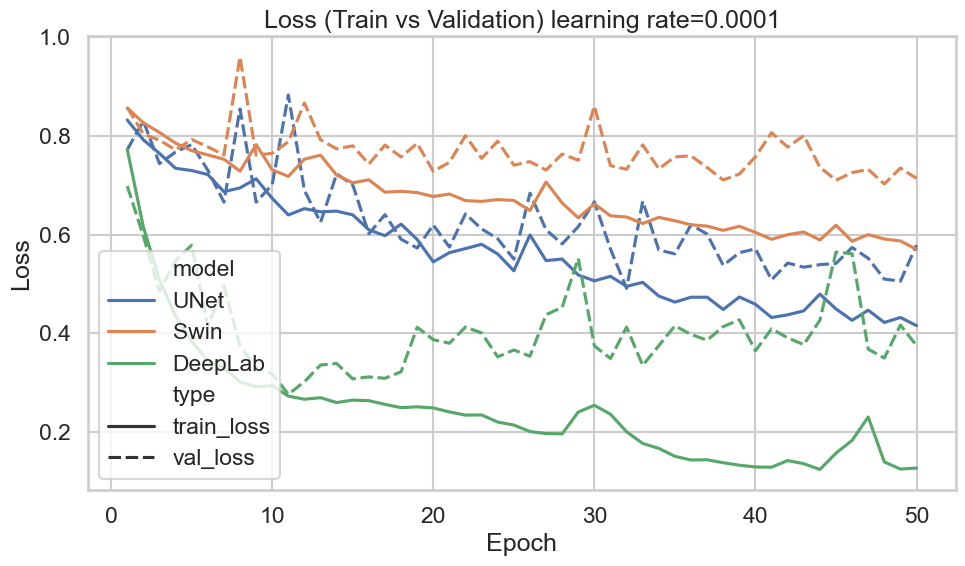

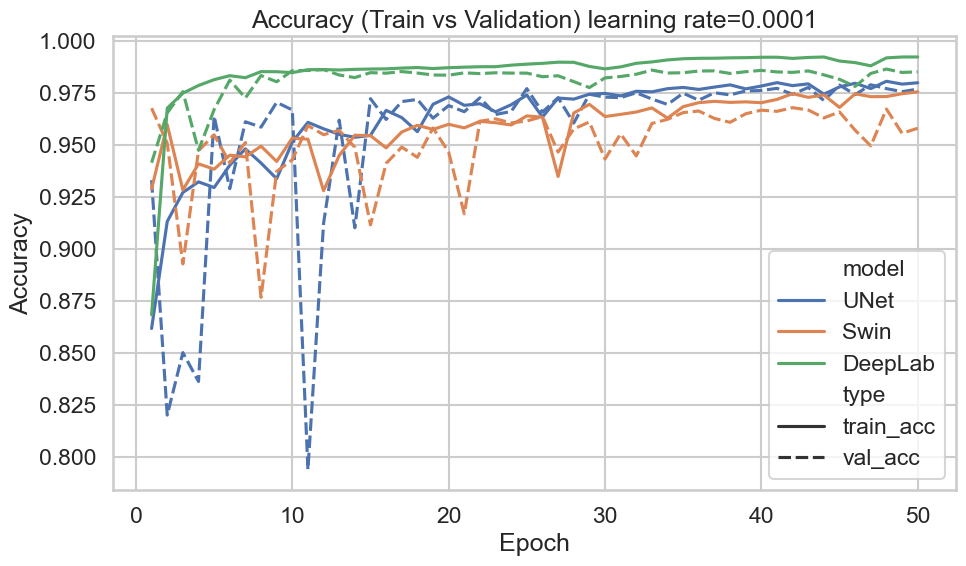

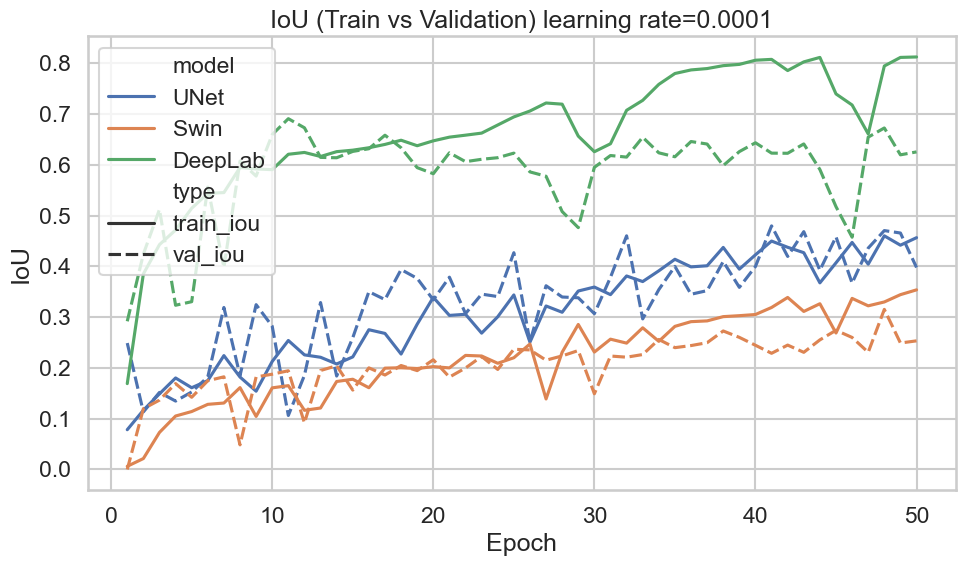

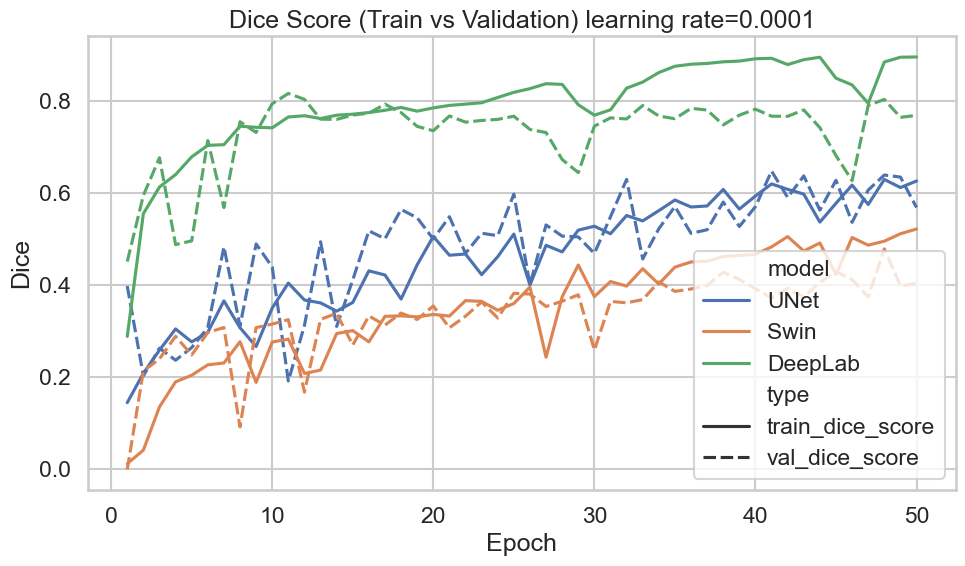

In [10]:
# -------------------------
# 1. LOSS
# -------------------------
loss_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_loss", "val_loss"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=loss_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Loss (Train vs Validation) learning rate={LR}")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()


# -------------------------
# 2. ACCURACY
# -------------------------
acc_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_acc", "val_acc"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=acc_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Accuracy (Train vs Validation) learning rate={LR}")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()


# -------------------------
# 3. IoU
# -------------------------
iou_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_iou", "val_iou"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=iou_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"IoU (Train vs Validation) learning rate={LR}")
plt.ylabel("IoU")
plt.xlabel("Epoch")

# # Optional: log scale for visibility
# plt.yscale("log")

plt.tight_layout()
plt.show()


# -------------------------
# 3. Dice Score
# -------------------------
iou_df = df.melt(
    id_vars=["epoch", "model"],
    value_vars=["train_dice_score", "val_dice_score"],
    var_name="type",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=iou_df, x="epoch", y="value", hue="model", style="type")
plt.title(f"Dice Score (Train vs Validation) learning rate={LR}")
plt.ylabel("Dice")
plt.xlabel("Epoch")

# # Optional: log scale for visibility
# plt.yscale("log")

plt.tight_layout()
plt.show()